# first try using partial least squares to extract components that predict week

### this notebook uses the pilot subject data in the maternal brain project to extract components from the meshes that best describe the gestational week using PLS. then we predict a mesh from the components and compute r2s. couple of visualization options are shown. at the end i attempt to use CCA by splitting the dataset into training/testing sets and see how well the 1 CCA component fits the data. i do not visualize the predicted meshes, and i'm not sure if i did this computation correctly. the conclusions from this are PLS is successful and predicting meshes from these components gives good meshes.

In [1]:
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import r2_score
from scipy.stats import pearsonr
import numpy as np

import os
import nibabel
from sklearn.decomposition import PCA
import pandas as pd

from pathlib import Path

import numpy as np
import pyvista as pv
from IPython.display import Image
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.preprocessing import SplineTransformer
from sklearn.pipeline import make_pipeline

import polpo.preprocessing.pd as ppd
from polpo.models import ObjectRegressor
from polpo.preprocessing import (
    IndexMap,
    Map,
    NestingSwapper,
    PartiallyInitializedStep,
)
from polpo.preprocessing.dict import DictMap, DictMerger
from polpo.preprocessing.load.pregnancy import (
    DenseMaternalCsvDataLoader,
    DenseMaternalMeshLoader,
)
from polpo.preprocessing.mesh.conversion import ToVertices
from polpo.preprocessing.mesh.io import PvReader
from polpo.preprocessing.mesh.registration import PvAlign
from polpo.sklearn.adapter import AdapterPipeline
from polpo.sklearn.mesh import BiMeshesToVertices
from polpo.sklearn.np import BiFlattenButFirst, FlattenButFirst

import logging
logging.getLogger().setLevel(logging.WARNING)

structure_key = {
    10: "Left-Thalamus-Proper",
    11: "Left-Caudate",
    12: "Left-Putamen",
    13: "Left-Pallidum",
    17: "Left-Hippocampus",
    18: "Left-Amygdala",
    49: "Right-Thalamus-Proper",
    50: "Right-Caudate",
    51: "Right-Putamen",
    52: "Right-Pallidum",
    53: "Right-Hippocampus",
    54: "Right-Amygdala",
}

pilot_shapes_dir = '/Users/sak/.herbrain/data/pregnancy/maternal_brain_project/pilot_engima_shape/derivatives/enigma_shape_hires_long'

def nibabel_to_pyvista(mesh):
    V = mesh[0]
    F = mesh[1]
    face_data = np.hstack(np.c_[np.full(len(F), 3), F]).astype(np.int64)
    return pv.PolyData(V, face_data)

df = pd.read_csv("/Users/sak/.herbrain/data/pregnancy/28Baby_Hormones.csv")
X = df["gestWeek"]

dataset_pipe = DictMerger() + NestingSwapper() + IndexMap(lambda x: np.array(x)[:, None], index=0)

weeks = np.array(X)

all_meshes = {}
for structure_id, structure_name in structure_key.items():
    print(f"\n=== Processing {structure_name} ({structure_id}) ===")
    brain_structure_filename = f"resliced_mesh_{structure_id}"
    mesh_paths = []

    for subdir in sorted(os.listdir(pilot_shapes_dir)):
        full_path = os.path.join(pilot_shapes_dir, subdir, brain_structure_filename)
        if os.path.exists(full_path):
            mesh_paths.append((subdir, full_path))

    aligned_meshes = {}
    reference_mesh = None

    for i_mesh, (name, path) in enumerate(mesh_paths):
        mesh = nibabel.freesurfer.read_geometry(path)
        pv_mesh = nibabel_to_pyvista(mesh)
        if i_mesh == 0:
            reference_mesh = pv_mesh
            aligned_meshes[i_mesh] = pv_mesh
        else:
            aligned = pv_mesh.align(
                reference_mesh,
                max_landmarks=100,
                max_mean_distance=1e-5,
                max_iterations=500,
                check_mean_distance=True,
                start_by_matching_centroids=True,
            )
            aligned_meshes[i_mesh] = aligned
    all_meshes[structure_id] = aligned_meshes

# all_meshes


=== Processing Left-Thalamus-Proper (10) ===

=== Processing Left-Caudate (11) ===

=== Processing Left-Putamen (12) ===

=== Processing Left-Pallidum (13) ===

=== Processing Left-Hippocampus (17) ===

=== Processing Left-Amygdala (18) ===

=== Processing Right-Thalamus-Proper (49) ===

=== Processing Right-Caudate (50) ===

=== Processing Right-Putamen (51) ===

=== Processing Right-Pallidum (52) ===

=== Processing Right-Hippocampus (53) ===

=== Processing Right-Amygdala (54) ===


In [2]:
for i,w in enumerate(weeks):
    print(i+1,w)
weeks_pregnancy_train = weeks[0:16]
weeks_postpartum_train = weeks[19:23]
weeks_to_predict_pregnancy = weeks[16:19]
weeks_to_predict_postpartum = weeks[23:26]

print(weeks_pregnancy_train)
print(weeks_to_predict_pregnancy)

print(weeks_postpartum_train)
print(weeks_to_predict_postpartum)

1 -3.0
2 -0.5
3 1.0
4 1.5
5 2.0
6 3.0
7 9.0
8 12.0
9 14.0
10 15.0
11 17.0
12 19.0
13 22.0
14 24.0
15 27.0
16 29.0
17 31.0
18 33.0
19 36.0
20 43.0
21 46.0
22 49.0
23 51.0
24 68.0
25 93.0
26 162.0
27 162.0
[-3.  -0.5  1.   1.5  2.   3.   9.  12.  14.  15.  17.  19.  22.  24.
 27.  29. ]
[31. 33. 36.]
[43. 46. 49. 51.]
[ 68.  93. 162.]


## slide 7 and 8 in presentation:
### PLS components for pregnancy weeks (sessions 0-16)
### test on sessions 17-19


Global R² for predicting week from shape (PREGNANCY): 0.998
Component 1: r = 0.905, p = 0.0000015, R² = 0.818
Component 2: r = 0.284, p = 0.2868518, R² = 0.081
Component 3: r = 0.297, p = 0.2631222, R² = 0.089
Component 4: r = 0.105, p = 0.6996894, R² = 0.011


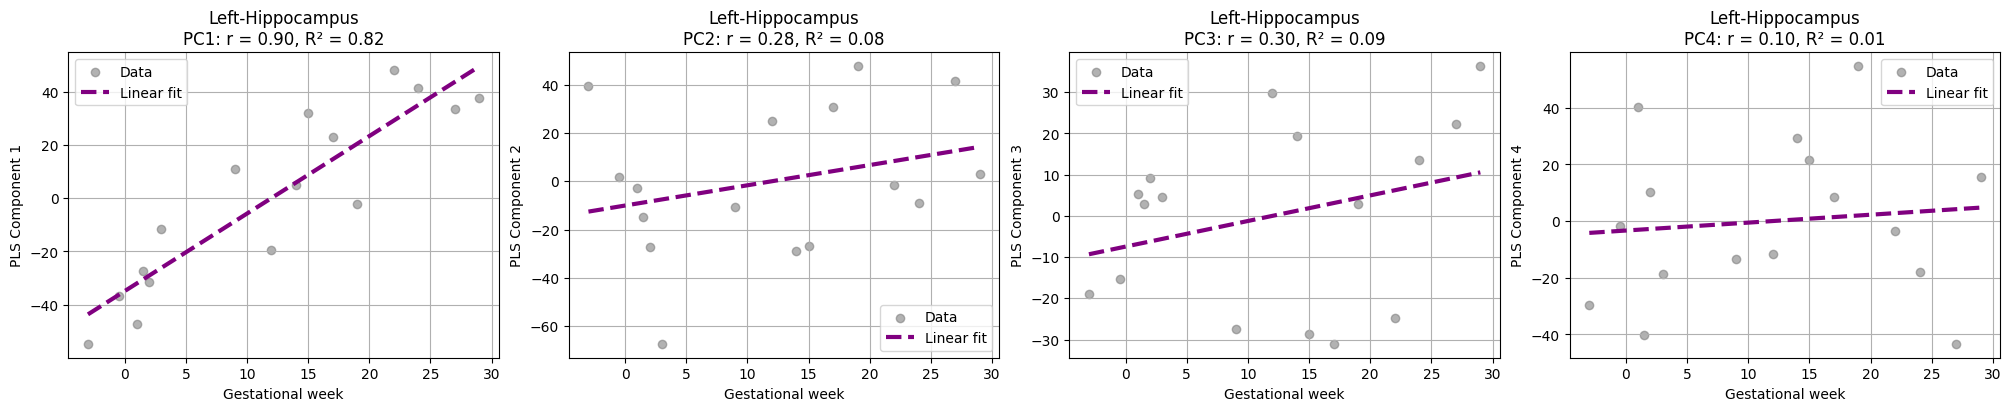

In [3]:
# just doing for the hippocampus for now for testing purposes
# PLS regression to find component of change in mesh best correlated with week
# and plotting each component and the linear regression fit line
# p values and r2s look nice :)
n_comps = 4
test_structure = (17,'Left-Hippocampus')
fig, axes = plt.subplots(1, n_comps, figsize=(5 * n_comps, 4), constrained_layout=True)

for structure_id, structure_name in [test_structure]:
    aligned_meshes = all_meshes[structure_id]
    all_mesh_points = []
    for session_id,_ in enumerate(weeks_pregnancy_train):
        mesh = aligned_meshes[session_id]
        all_mesh_points.append(mesh.points)

    weeks_y = weeks_pregnancy_train

    verts_reshaped = np.array(all_mesh_points).reshape(len(weeks_pregnancy_train), -1)
    # print(verts_reshaped.shape)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(verts_reshaped)

    y = weeks_y.reshape(-1, 1)
    # print(y.shape)

    pls = PLSRegression(n_components=n_comps)
    pls.fit(X_scaled, y)
    pls_scores = pls.x_scores_

    # Overall R2
    r2_total = pls.score(X_scaled, y)
    print(f"\nGlobal R² for predicting week from shape (PREGNANCY): {r2_total:.3f}")

    reg = LinearRegression().fit(y, pls_scores)

    # predict mesh at future weeks
    predicted_meshes_pregnancy = {}
    for w in weeks_to_predict_pregnancy:
        scores_pred = reg.predict([[w]])  # predict shape latent vector
        X_pred_scaled = np.dot(scores_pred, pls.x_loadings_.T)
        X_pred = scaler.inverse_transform(X_pred_scaled)
        mesh_pred = X_pred.reshape(-1, 3)
        predicted_meshes_pregnancy[w] = mesh_pred  # store reconstructed mesh

    # Plot PLS components vs. week
    for comp in range(n_comps):
        ax = axes[comp]
        y_comp = pls_scores[:, comp]
        x_week = y

        # correlation
        corr, pval = pearsonr(y_comp, weeks_y)

        # print(x_week.shape)
        # print(y_comp.shape)

        lr = LinearRegression().fit(x_week, y_comp)
        y_fit = lr.predict(x_week)
        r2 = r2_score(y_comp, y_fit)

        # Print stats
        print(f"Component {comp+1}: r = {corr:.3f}, p = {pval:.7f}, R² = {r2:.3f}")

        # Plot scatter + regression
        ax.scatter(weeks_y, y_comp, label='Data', color='gray', alpha=0.6)
        x_line = np.linspace(x_week.min(), x_week.max(), 100).reshape(-1, 1)
        y_line = lr.predict(x_line)
        ax.plot(x_line, y_line, color='purple', linestyle='--', label='Linear fit', linewidth=3)

        ax.set_xlabel("Gestational week")
        ax.set_ylabel(f"PLS Component {comp + 1}")
        ax.set_title(f"{test_structure[1]}\nPC{comp+1}: r = {corr:.2f}, R² = {r2:.2f}")
        ax.grid(True)
        ax.legend()

plt.savefig(f"svgs/pls_components_{test_structure}_pregnancy.svg", format='svg')
plt.show()


In [4]:
predicted_meshes_pregnancy

{np.float64(31.0): array([[153.42254852, 135.6801313 , 110.56187129],
        [153.83179921, 136.07319177, 110.54639428],
        [153.24037114, 133.99172179, 111.17449628],
        ...,
        [142.67008429, 149.29034764, 146.82444422],
        [143.38455235, 149.53360674, 147.19375275],
        [143.00219932, 148.93483418, 147.34624818]], shape=(2502, 3)),
 np.float64(33.0): array([[153.43249437, 135.70965979, 110.56201269],
        [153.84195696, 136.09651918, 110.5467509 ],
        [153.24908741, 134.01366738, 111.17040708],
        ...,
        [142.67341645, 149.26816225, 146.79227801],
        [143.39363167, 149.51572857, 147.16137758],
        [143.00866972, 148.92219036, 147.31496925]], shape=(2502, 3)),
 np.float64(36.0): array([[153.44741315, 135.75395254, 110.5622248 ],
        [153.85719359, 136.13151031, 110.54728583],
        [153.26216181, 134.04658578, 111.16427328],
        ...,
        [142.67841469, 149.23488417, 146.7440287 ],
        [143.40725064, 149.48891132, 


Global R² for predicting week from shape (PREGNANCY): 0.999
Component 1: r = 0.901, p = 0.0000019, R² = 0.811
Component 2: r = -0.324, p = 0.2216100, R² = 0.105
Component 3: r = 0.275, p = 0.3022815, R² = 0.076
Component 4: r = -0.086, p = 0.7515320, R² = 0.007


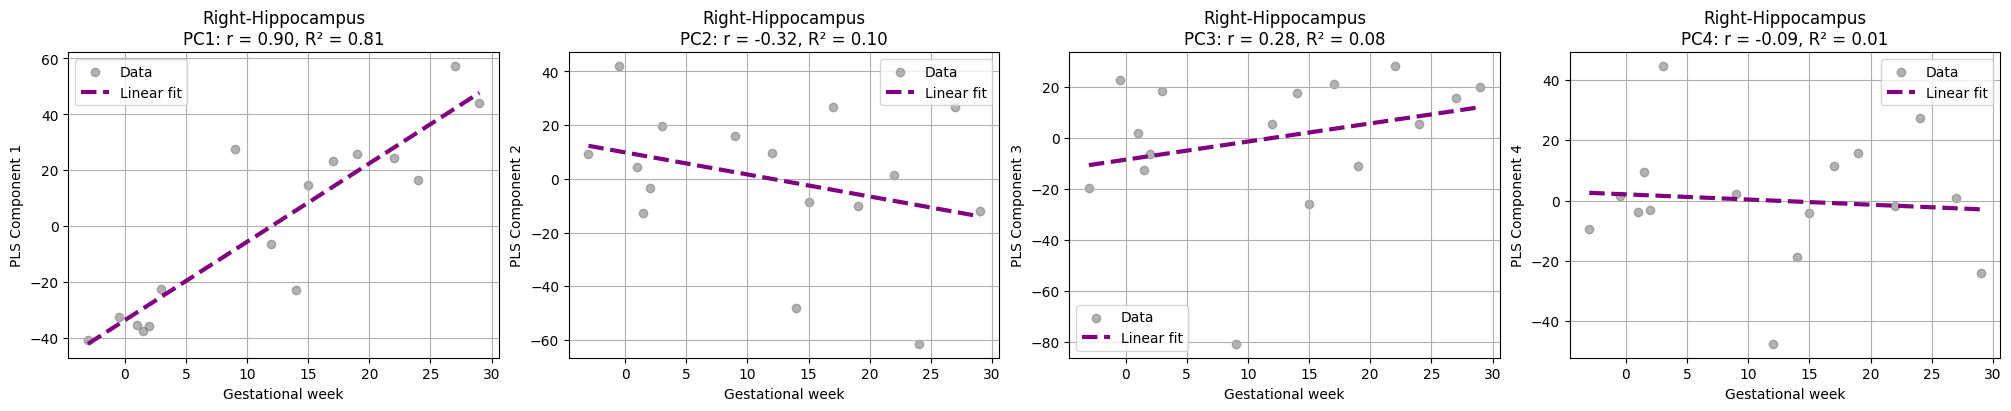

In [5]:
# RIGHT HIPPOCAMPUS
test_structure = (53,'Right-Hippocampus')
fig, axes = plt.subplots(1, n_comps, figsize=(5 * n_comps, 4), constrained_layout=True)

for structure_id, structure_name in [test_structure]:
    aligned_meshes = all_meshes[structure_id]
    all_mesh_points = []
    for session_id,_ in enumerate(weeks_pregnancy_train):
        mesh = aligned_meshes[session_id]
        all_mesh_points.append(mesh.points)

    weeks_y = weeks_pregnancy_train

    verts_reshaped = np.array(all_mesh_points).reshape(len(weeks_pregnancy_train), -1)
    # print(verts_reshaped.shape)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(verts_reshaped)

    y = weeks_y.reshape(-1, 1)
    # print(y.shape)

    pls = PLSRegression(n_components=n_comps)
    pls.fit(X_scaled, y)
    pls_scores = pls.x_scores_

    # Overall R2
    r2_total = pls.score(X_scaled, y)
    print(f"\nGlobal R² for predicting week from shape (PREGNANCY): {r2_total:.3f}")

    reg = LinearRegression().fit(y, pls_scores)

    # predict mesh at future weeks
    predicted_meshes_pregnancy = {}
    for w in weeks_to_predict_pregnancy:
        scores_pred = reg.predict([[w]])  # predict shape latent vector
        X_pred_scaled = np.dot(scores_pred, pls.x_loadings_.T)
        X_pred = scaler.inverse_transform(X_pred_scaled)
        mesh_pred = X_pred.reshape(-1, 3)
        predicted_meshes_pregnancy[w] = mesh_pred  # store reconstructed mesh

    # Plot PLS components vs. week
    for comp in range(n_comps):
        ax = axes[comp]
        y_comp = pls_scores[:, comp]
        y_comp = -pls_scores[:, comp]
        x_week = y

        # correlation
        corr, pval = pearsonr(y_comp, weeks_y)

        # print(x_week.shape)
        # print(y_comp.shape)

        lr = LinearRegression().fit(x_week, y_comp)
        y_fit = lr.predict(x_week)
        r2 = r2_score(y_comp, y_fit)

        # Print stats
        print(f"Component {comp+1}: r = {corr:.3f}, p = {pval:.7f}, R² = {r2:.3f}")

        # Plot scatter + regression
        ax.scatter(weeks_y, y_comp, label='Data', color='gray', alpha=0.6)
        x_line = np.linspace(x_week.min(), x_week.max(), 100).reshape(-1, 1)
        y_line = lr.predict(x_line)
        
        ax.plot(x_line, y_line, color='purple', linestyle='--', label='Linear fit', linewidth=3)
        # ax.invert_yaxis()

        ax.set_xlabel("Gestational week")
        ax.set_ylabel(f"PLS Component {comp + 1}")
        ax.set_title(f"{test_structure[1]}\nPC{comp+1}: r = {corr:.2f}, R² = {r2:.2f}")
        ax.grid(True)
        ax.legend()

plt.savefig(f"svgs/pls_components_{test_structure}_pregnancy.svg", format='svg')
plt.show()


## slide 7 and 8 in presentation:
### PLS components for postpartum weeks (sessions 20-24)
### test on sessions 25-27
#### doing this on just the pilot data isn't amazing because there are so few data points
#### 

/Users/sak/anaconda3/envs/herbrain/lib/python3.11/site-packages/sklearn/cross_decomposition/_pls.py:348: UserWarning: y residual is constant at iteration 3
  warnings.warn(f"y residual is constant at iteration {k}")
/var/folders/1h/ygmxfx2933lg3n47qtxn__440000gp/T/ipykernel_4822/1032581812.py:51: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = pearsonr(y_comp, weeks_y)



Global R² for predicting week from shape (POSTPARTUM): 1.000
Component 1: r = -0.994, p = 0.0062369, R² = 0.988
Component 2: r = -0.111, p = 0.8890410, R² = 0.012
Component 3: r = 0.011, p = 0.9889093, R² = 0.000
Component 4: r = nan, p = nan, R² = 1.000


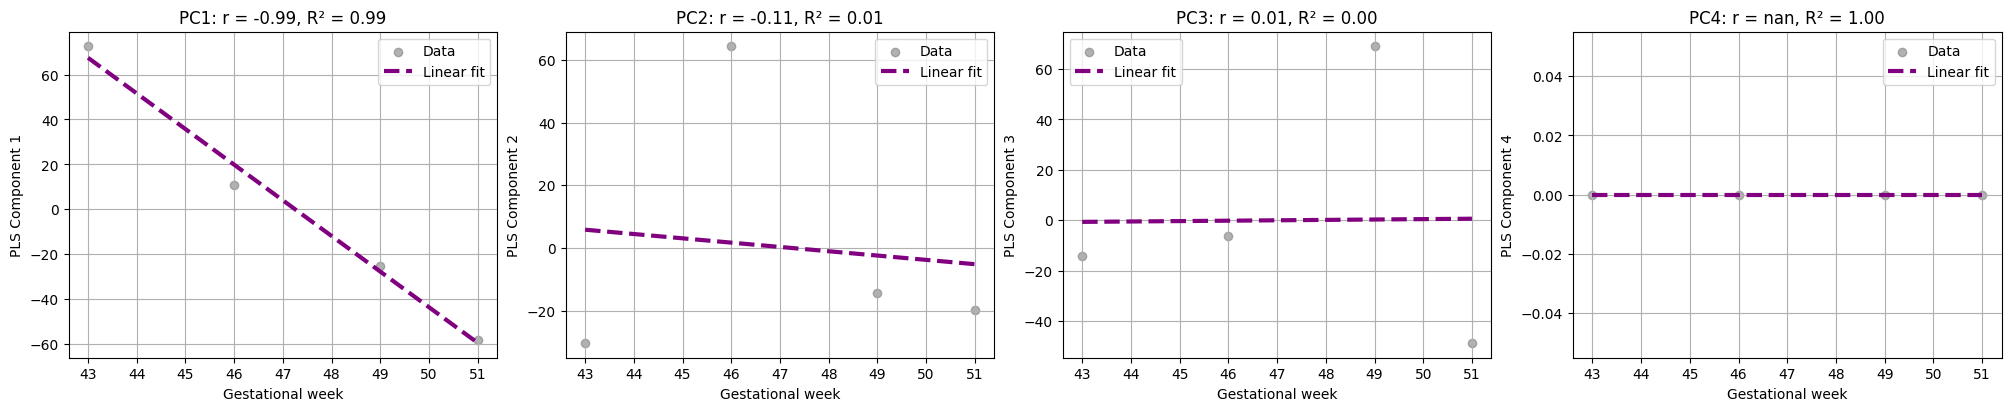

In [6]:
# just doing for the hippocampus for now for testing purposes
# PLS regression to find component of change in mesh best correlated with week
# and plotting each component and the linear regression fit line
# p values and r2s look nice :)
test_structure = (17,'Left-Hippocampus')
fig, axes = plt.subplots(1, n_comps, figsize=(5 * n_comps, 4), constrained_layout=True)

for structure_id, structure_name in [test_structure]:
    aligned_meshes = all_meshes[structure_id]
    all_mesh_points = []
    for session_id,_ in enumerate(weeks_postpartum_train):
        mesh = aligned_meshes[session_id]
        all_mesh_points.append(mesh.points)

    weeks_y = weeks_postpartum_train

    verts_reshaped = np.array(all_mesh_points).reshape(len(weeks_postpartum_train), -1)
    # print(verts_reshaped.shape)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(verts_reshaped)

    y = weeks_y.reshape(-1, 1)
    # print(y.shape)

    pls = PLSRegression(n_components=n_comps)
    pls.fit(X_scaled, y)
    pls_scores = pls.x_scores_

    # Overall R2
    r2_total = pls.score(X_scaled, y)
    print(f"\nGlobal R² for predicting week from shape (POSTPARTUM): {r2_total:.3f}")

    reg = LinearRegression().fit(y, pls_scores)

    # predict mesh at future weeks
    predicted_meshes_postpartum = {}
    for w in weeks_to_predict_postpartum:
        scores_pred = reg.predict([[w]])  # predict shape latent vector
        X_pred_scaled = np.dot(scores_pred, pls.x_loadings_.T)
        X_pred = scaler.inverse_transform(X_pred_scaled)
        mesh_pred = X_pred.reshape(-1, 3)
        predicted_meshes_postpartum[w] = mesh_pred  # store reconstructed mesh

    # Plot PLS components vs. week
    for comp in range(n_comps):
        ax = axes[comp]
        y_comp = pls_scores[:, comp]
        x_week = y

        # correlation
        corr, pval = pearsonr(y_comp, weeks_y)

        # print(x_week.shape)
        # print(y_comp.shape)

        lr = LinearRegression().fit(x_week, y_comp)
        y_fit = lr.predict(x_week)
        r2 = r2_score(y_comp, y_fit)

        # Print stats
        print(f"Component {comp+1}: r = {corr:.3f}, p = {pval:.7f}, R² = {r2:.3f}")

        # Plot scatter + regression
        ax.scatter(weeks_y, y_comp, label='Data', color='gray', alpha=0.6)
        x_line = np.linspace(x_week.min(), x_week.max(), 100).reshape(-1, 1)
        y_line = lr.predict(x_line)
        ax.plot(x_line, y_line, color='purple', linestyle='--', label='Linear fit', linewidth=3)

        ax.set_xlabel("Gestational week")
        ax.set_ylabel(f"PLS Component {comp + 1}")
        ax.set_title(f"PC{comp+1}: r = {corr:.2f}, R² = {r2:.2f}")
        ax.grid(True)
        ax.legend()

plt.savefig(f"svgs/pls_components_{test_structure}_pregnancy.svg", format='svg')
plt.show()


In [7]:
for week in weeks_to_predict_pregnancy:
    print(X[X == week].index[0])
    m = all_meshes[17][X[X == week].index[0]].points
    print(m.shape)

16
(2502, 3)
17
(2502, 3)
18
(2502, 3)


In [8]:
pls

PLSRegression(n_components=4)

In [9]:
def compute_rmsd(pred, true):
    #Compute RMS deviation between two meshes
    assert pred.shape == true.shape
    return np.sqrt(np.mean(np.sum((pred - true) ** 2, axis=1)))

def compute_diameter(mesh):
    # compute mesh diameter as max pairwise vertex distance
    from scipy.spatial.distance import pdist
    return np.max(pdist(mesh))

true_pls_scores = []
predicted_pls_scores = []
true_meshes_flat = []
pred_meshes_flat = []
print("\nRMSD Errors (normalized by mesh diameter -- PREGNANCY):")
for week in weeks_to_predict_pregnancy:
    pred_mesh = predicted_meshes_pregnancy[week]

    # find the closest ground truth week
    idx = np.argmin(np.abs(weeks - week))
    true_mesh = all_meshes[53][X[X == week].index[0]].points

    rmsd = compute_rmsd(pred_mesh, true_mesh)
    diameter = compute_diameter(true_mesh)
    rel_error = rmsd / diameter

    print(f"  Week {week}: RMSD = {rmsd:.4f}, Diameter = {diameter:.4f}, Relative Error = {rel_error:.2%}")

    # Flatten the meshes
    true_flat = true_mesh.flatten().reshape(1, -1)
    pred_flat = pred_mesh.flatten().reshape(1, -1)

    # Compute PLS scores
    true_pls = pls.transform(true_flat)
    pred_pls = pls.transform(pred_flat)

    true_pls_scores.append(true_pls[0])  # store as 1D array
    predicted_pls_scores.append(pred_pls[0])

    # Store vertex data for R²
    true_meshes_flat.append(true_flat[0])
    pred_meshes_flat.append(pred_flat[0])

# Convert to arrays for R²
true_pls_scores = np.array(true_pls_scores)
predicted_pls_scores = np.array(predicted_pls_scores)
true_meshes_flat = np.array(true_meshes_flat)
pred_meshes_flat = np.array(pred_meshes_flat)

# Compute R²
r2_pls = r2_score(true_pls_scores, predicted_pls_scores)
r2_vertices = r2_score(true_meshes_flat, pred_meshes_flat)

print(f"\nOverall R² in PLS space: {r2_pls:.3f}")
print(f"Overall R² in vertex space: {r2_vertices:.3f}")



RMSD Errors (normalized by mesh diameter -- PREGNANCY):
  Week 31.0: RMSD = 0.4803, Diameter = 41.7934, Relative Error = 1.15%
  Week 33.0: RMSD = 0.4603, Diameter = 41.7337, Relative Error = 1.10%
  Week 36.0: RMSD = 0.7160, Diameter = 41.9305, Relative Error = 1.71%

Overall R² in PLS space: -0.563
Overall R² in vertex space: -4.397


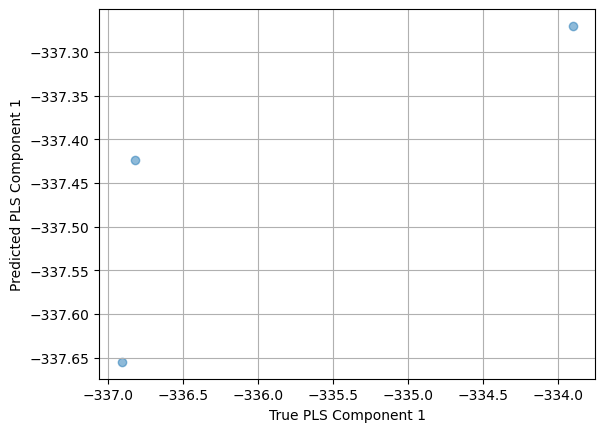

In [10]:
plt.scatter(true_pls_scores[:, 0], predicted_pls_scores[:, 0], alpha=0.5)
plt.xlabel("True PLS Component 1")
plt.ylabel("Predicted PLS Component 1")
plt.grid(True)
plt.show()

## slide 7 in presentation: the primary shape change associated with pregnancy, postpartum
### since component 1 from PLS (for pregnancy) has the highest R2 value, we visualize the deformation changes along component 1
### similarly, component 1 from PLS (for postpartum) has the highest R2, so we look at changes along component 1

In [11]:
from ipywidgets import interact, IntSlider

def interactive_pls_slider(
    mean_shape, direction, faces,
    alpha_max=30.0, n_frames=60, comp_id=0, stage='PREGNANCY', structure=17
):
    alphas = np.linspace(-alpha_max, alpha_max, n_frames)
    meshes = []

    max_disp = np.max(np.linalg.norm(alpha_max * direction, axis=1))
    scalar_range = (-max_disp, max_disp)

    # Precompute all deformed meshes
    for alpha in alphas:
        deformed = mean_shape + alpha * direction
        deformed = deformed.reshape(-1, 3)
        displacement = np.dot(direction, np.ones(3)) * alpha  # signed magnitude
        mesh = pv.PolyData(deformed, faces)
        mesh["Displacement"] = displacement
        meshes.append(mesh)

    # Create a plotter for Jupyter
    plotter = pv.Plotter(notebook=True)
    # Add mesh with fixed colormap range
    actor = plotter.add_mesh(
        meshes[0],
        scalars="Displacement",
        cmap="coolwarm",
        clim=scalar_range
    )
    plotter.add_title(f"PLS Component {comp_id + 1} | alpha = {alphas[0]:.2f}", font_size=10)
    # text_actor = plotter.add_text(f"PLS Component {comp_id + 1} | alpha = {alphas[0]:.2f}", font_size=10)
    plotter.show(auto_close=False)

    # Slider function
    def update(frame_idx):
        mesh = meshes[frame_idx]
        actor.mapper.SetInputData(mesh)
        plotter.add_title(f"PLS Component {comp_id + 1} | stage {stage} | {structure_key[structure]} | alpha = {alphas[frame_idx]:.2f}", font_size=10)
        plotter.render()

    interact(update, frame_idx=IntSlider(min=0, max=n_frames - 1, step=1, value=0))


In [14]:
# PREGNANCY INTERACTIVE SLIDER ALONG COMPONENT 1
for structure_id, structure_name in [(17,'Left-Hippocampus')]:
    aligned_meshes = all_meshes[structure_id]
    all_mesh_points = []
    faces = []
    # for session_id in range(start_session_pregnancy, end_session_pregnancy+1):
    for session_id,_ in enumerate(weeks_postpartum_train):
        mesh = aligned_meshes[session_id]
        faces = mesh.faces
        all_mesh_points.append(mesh.points)
    verts_reshaped = np.array(all_mesh_points).reshape(len(all_mesh_points), 3 * len(all_mesh_points[0]))

    # get mean shape and component directions
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(verts_reshaped)
    
    mean_shape_pregnancy = scaler.mean_
    weights_pregnancy = pls.x_weights_  # shape: (n_features, n_components)
    
    comp_id = 0  # 0-based index for component
    alpha = 3  # exaggeration factor for visualization
    
    direction = weights_pregnancy[:, comp_id]  # shape (n_vertices * 3,)
    
    # Mean ± alpha × component
    shape_plus = mean_shape_pregnancy + alpha * direction
    shape_minus = mean_shape_pregnancy - alpha * direction
    
    shape_mean = mean_shape_pregnancy.reshape(-1, 3)
    shape_plus = shape_plus.reshape(-1, 3)
    shape_minus = shape_minus.reshape(-1, 3)

interactive_pls_slider(mean_shape_pregnancy.reshape(-1, 3), direction.reshape(-1, 3), faces, comp_id=0, stage='PREGNANCY', structure=17)

Widget(value='<iframe src="http://localhost:50160/index.html?ui=P_0x32b9ce150_2&reconnect=auto" class="pyvista…

interactive(children=(IntSlider(value=0, description='frame_idx', max=59), Output()), _dom_classes=('widget-in…

In [13]:
# PREGNANCY INTERACTIVE SLIDER ALONG COMPONENT 1
for structure_id, structure_name in [(53,'Right-Hippocampus')]:
    aligned_meshes = all_meshes[structure_id]
    all_mesh_points = []
    faces = []
    for session_id,_ in enumerate(weeks_pregnancy_train):
        mesh = aligned_meshes[session_id]
        faces = mesh.faces
        all_mesh_points.append(mesh.points)
    verts_reshaped = np.array(all_mesh_points).reshape(len(all_mesh_points), 3 * len(all_mesh_points[0]))


    # get mean shape and component directions
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(verts_reshaped)
    
    mean_shape_pregnancy = scaler.mean_
    weights_pregnancy = pls.x_weights_  # shape: (n_features, n_components)
    
    comp_id = 0  # 0-based index for component
    alpha = 3  # exaggeration factor for visualization
    
    direction = weights_pregnancy[:, comp_id]  # shape (n_vertices * 3,)
    
    # Mean ± alpha × component
    shape_plus = mean_shape_pregnancy + alpha * direction
    shape_minus = mean_shape_pregnancy - alpha * direction
    
    shape_mean = mean_shape_pregnancy.reshape(-1, 3)
    shape_plus = shape_plus.reshape(-1, 3)
    shape_minus = shape_minus.reshape(-1, 3)

interactive_pls_slider(mean_shape_pregnancy.reshape(-1, 3), direction.reshape(-1, 3), faces, comp_id=0, stage='PREGNANCY', structure=53)

Widget(value='<iframe src="http://localhost:50160/index.html?ui=P_0x17df83f50_1&reconnect=auto" class="pyvista…

interactive(children=(IntSlider(value=0, description='frame_idx', max=59), Output()), _dom_classes=('widget-in…

In [17]:
# POSTPARTUM INTERACTIVE SLIDER ALONG COMPONENT 1
for structure_id, structure_name in [(17,'Left-Hippocampus')]:
    aligned_meshes = all_meshes[structure_id]
    all_mesh_points = []
    for session_id,_ in enumerate(weeks_postpartum_train):
        mesh = aligned_meshes[session_id]
        all_mesh_points.append(mesh.points)
    verts_reshaped = np.array(all_mesh_points).reshape(len(all_mesh_points), 3 * len(all_mesh_points[0]))

    # get mean shape and component directions
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(verts_reshaped)
    
    mean_shape_postpartum = scaler.mean_
    weights_postpartum = pls.x_weights_  # shape: (n_features, n_components)
    
    comp_id = 0  # 0-based index for component
    alpha = 3  # exaggeration factor for visualization
    
    direction = weights_postpartum[:, comp_id]  # shape (n_vertices * 3,)
    
    # Mean ± alpha × component
    shape_plus = mean_shape_postpartum + alpha * direction
    shape_minus = mean_shape_postpartum - alpha * direction
    
    shape_mean = mean_shape_postpartum.reshape(-1, 3)
    shape_plus = shape_plus.reshape(-1, 3)
    shape_minus = shape_minus.reshape(-1, 3)


interactive_pls_slider(mean_shape_postpartum.reshape(-1, 3), direction.reshape(-1, 3), faces, comp_id=0, stage='POSTPARTUM')

Widget(value='<iframe src="http://localhost:50160/index.html?ui=P_0x30e1e0c90_3&reconnect=auto" class="pyvista…

interactive(children=(IntSlider(value=0, description='frame_idx', max=59), Output()), _dom_classes=('widget-in…

In [18]:
# this visualization is better than the overlays but not as good as just colormapping deformations onto the vertices
def show_mesh_error_arrows(true_mesh, predicted_mesh, faces, week=None, scale=1.0):
    # arrows from true_mesh to predicted_mesh to visualize pointwise errors
    
    assert true_mesh.shape == predicted_mesh.shape

    vectors = predicted_mesh - true_mesh
    magnitudes = np.linalg.norm(vectors, axis=1)

    base = pv.PolyData(true_mesh, faces)
    base["vectors"] = vectors
    base["error"] = magnitudes

    arrows = base.glyph(orient="vectors", scale="error", factor=scale)

    # Plot
    plotter = pv.Plotter(window_size=(800, 600))
    plotter.add_mesh(base, color='lightgray', opacity=0.5, label='Ground Truth')
    plotter.add_mesh(arrows, color='red', label='Error Vectors')

    if week is not None:
        plotter.add_text(f"Error Arrows at Week {week}", position="upper_edge", font_size=14)

    plotter.add_legend()
    plotter.show()

week = 31
pred = predicted_meshes[week]
true = all_meshes[17][X[X == week].index[0]].points

show_mesh_error_arrows(true, pred, faces, week=week, scale=.5)


NameError: name 'predicted_meshes' is not defined

In [16]:
from scipy.spatial.distance import pdist

def compute_rmsd(pred, true):
    return np.sqrt(np.mean(np.sum((pred - true) ** 2, axis=1)))

def compute_diameter(mesh):
    return np.max(pdist(mesh))

def visualize_pointwise_error_row(predicted_meshes, weeks_to_predict_pregnancy, all_meshes, weeks_pregnancy, X):
    """
    Show pointwise error plots in a row for multiple predicted meshes.
    Titles include percent error relative to mesh diameter.
    """
    n = len(weeks_to_predict_pregnancy)
    plotter = pv.Plotter(shape=(1, n), window_size=(350 * n, 500))

    for i, week in enumerate(weeks_to_predict_pregnancy):
        pred_mesh = predicted_meshes[week]

        # Get ground truth mesh
        idx = np.argmin(np.abs(weeks_pregnancy - week))
        true_mesh = all_meshes[17][X[X == week].index[0]]
        true_points = true_mesh.points
        faces = true_mesh.faces

        # Compute error map
        error = np.linalg.norm(pred_mesh - true_points, axis=1)
        mesh = pv.PolyData(pred_mesh, faces)
        mesh["Error"] = error

        # Compute normalized error
        rmsd = compute_rmsd(pred_mesh, true_points)
        diameter = compute_diameter(true_points)
        rel_error = 100 * rmsd / diameter

        # Add subplot
        plotter.subplot(0, i)
        plotter.add_mesh(mesh, scalars="Error", cmap="plasma", show_edges=False)
        plotter.add_text(f"Week {week} — {rel_error:.3f}%", font_size=10)
        plotter.view_xy()

    plotter.link_views()
    plotter.show()

visualize_pointwise_error_row(predicted_meshes, weeks_to_predict, all_meshes, weeks, X)


NameError: name 'predicted_meshes' is not defined